# Predicting patient survival using Support2 Data

## 1. Load libraries

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from ucimlrepo import fetch_ucirepo


from scipy.stats import gaussian_kde    # We use this to plot kernel density

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping



## 2. Data ingestion 

### 2.1 Read original data from UCI repo

In [126]:
# 880 is the ID for the Support2 data.
#support2 = fetch_ucirepo(id=880)

url = "https://archive.ics.uci.edu/static/public/880/data.csv"
df = pd.read_csv(url)
# Load the entire dataset into a pandas dataframe
# support2.data.features does not include some variables that we are interested
#df = support2.data.original
display(df.head(n=2))

# Summary print outs
print(50*"+-")
print("Online data dictionary")
print("https://archive.ics.uci.edu/dataset/880/support2")

print(50*"+-")
print("Column names:\n", df.columns)

print(50*"+-")
print("Shape of the data: ", df.shape)

print(50*"+-")
print("'slos' column contains NA or null?")
print(df.slos.isna().any() == 1)


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0


+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Online data dictionary
https://archive.ics.uci.edu/dataset/880/support2
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Column names:
 Index(['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Shape of the data:  (9105, 48)
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-

### 2.2 Subsetting data to patients passed away in hospital

In [127]:
# Limiting the examples to patients passed away while hospitalized
df = df[df.hospdead == 1]
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2360 entries, 1 to 9103
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2360 non-null   int64  
 1   age       2360 non-null   float64
 2   death     2360 non-null   int64  
 3   sex       2360 non-null   object 
 4   hospdead  2360 non-null   int64  
 5   slos      2360 non-null   int64  
 6   d.time    2360 non-null   int64  
 7   dzgroup   2360 non-null   object 
 8   dzclass   2360 non-null   object 
 9   num.co    2360 non-null   int64  
 10  edu       1747 non-null   float64
 11  income    1465 non-null   object 
 12  scoma     2359 non-null   float64
 13  charges   2299 non-null   float64
 14  totcst    2084 non-null   float64
 15  totmcst   1317 non-null   float64
 16  avtisst   2353 non-null   float64
 17  race      2341 non-null   object 
 18  sps       2359 non-null   float64
 19  aps       2359 non-null   float64
 20  surv2m    2359 non-null   float64
 

None

### 2.3 Select Columns

In [128]:
# Now that we selected patients 
# Check that the value of "death" and "hospdead" is uniformly "1".
print(50*"+-")
print("'death' and 'hospdeath' columns are all '1's?")
print(df.death.unique().all() == 1 and df.hospdead.unique().all() == 1)

# Drop columns that are now constant or irrelevant
df.drop(columns=["death", "hospdead", "id", "d.time", 
                 "dzclass", "charges", "totcst", "totmcst", 
                 "prg2m", "prg6m", "dnrday", "adlp", 
                 "adls", "meanbp", "avtisst"], inplace=True)



+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
'death' and 'hospdeath' columns are all '1's?
True


## 3 Feature preprocessing

### 3.1 Missing and bad values

In [129]:
# Missing value in features ["sps", "aps", "surv2m", "surv6m"]. 
# It turns out there is exactly one missing value for all these four features.

cols = ["sps", "aps", "surv2m", "surv6m", "scoma"]
df["sps_aps_surv_missing"] = df[cols].isna().any(axis=1).astype(int)
df[cols]

impute_values = {
    "sps": df["sps"].mean(),       #  
    "aps": df["aps"].mean(),
    "surv2m": df["surv2m"].mean(),
    "surv6m": df["surv6m"].mean(),
    "scoma": df["scoma"].mean()
}

df[cols] = df[cols].fillna(impute_values)


df["dnr"] = df["dnr"].fillna("missing")
df["income"] = df["income"].fillna("missing")
df["race"] = df["race"].fillna("missing")
df["sfdm2"] = df["sfdm2"].fillna("missing")

df["wblc"] = df["wblc"].fillna(9) # Using data curator's suggested fill-in value for missing value
df["pafi"] = df["pafi"].fillna(333.3) # Using data curator's suggested fill-in value for missing value
df["alb"] = df["alb"].fillna(3.5) # Using data curator's suggested fill-in value for missing value
df["bili"] = df["bili"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["crea"] = df["crea"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["bun"] = df["bun"].fillna(6.51) # Using data curator's suggested fill-in value for missing value
df["urine"] = df["urine"].fillna(2502) # Using data curator's suggested fill-in value for missing value

df["ph"] = df["ph"].fillna(df["ph"].median()) # It makes sense to replace missing ph with sample median
df["glucose"] = df["glucose"].fillna(df["glucose"].median()) # It makes sense to replace missing ph with sample median

df["resp"] = df["resp"].replace(0, np.nan)
df["resp"] = df["resp"].fillna(df["resp"].median()) # It doesn't make sense to have 0 resperation rate!

df["hrt"] = df["hrt"].replace([0, 1], np.nan)
df["hrt"] = df["hrt"].fillna(df["hrt"].median()) # It doesn't make sense to have 0 heart rate!




# Define a function that turns education years into bins including 'missing'
def edu_bins(edu):
    if pd.isna(edu):
        return "missing"
    elif edu < 12:
        return "pre_hs" # did not complete highschool 
    elif edu == 12:
        return "hs"
    elif edu < 16:
        return "some_college"
    else:
        return "college_or_higher"

df["edu_bins"] = df.edu.apply(edu_bins)
df["edu_bins"]
df.drop(columns=["edu"], inplace=True)



### 3.2 Outcome variables (choose one for each task)

In [130]:
# Median-based binary
slos_median = df["slos"].median()
df["slos_bin_median"] = (df["slos"] > slos_median).astype(int)

# extreme_2_class: [0–5], [30+]
def extreme_2_class(x):
    if x <= 5:
        return 0
    elif x >= 30:
        return 1
    else:
        return 2
df["slos_2_extreme_class"] = df["slos"].apply(extreme_2_class)

# 30-day binary
df["slos_bin_30"] = (df["slos"] > 30).astype(int)

# 3-class: [0–7], (7–30], (30+]
def slos_3class(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    else:
        return 2

df["slos_3class_7_30"] = df["slos"].apply(slos_3class)

# 5-class: [0–7], (7–30], (30–60], (60–180], (180+]
def slos_5class_fixed(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    elif x <= 60:
        return 2
    elif x <= 180:
        return 3
    else:
        return 4

df["slos_5class_fixed"] = df["slos"].apply(slos_5class_fixed)

# 5-class: quintiles (equal-sized bins)
df["slos_5class_quantile"] = pd.qcut(df["slos"], q=5, labels=False)


### 3.3 Encode categorical features

In [131]:
categorical_features = ["sex", "dzgroup", "income", "race",
                        "ca", "dnr", "sfdm2", "edu_bins"]


df = pd.get_dummies(df, columns=categorical_features, drop_first=True)


## 4. Select outcome variable for the learning task

### 4.1 Define a function to pick outcome variable

In [132]:
def select_outcome(df, outcome_col):
    """
    Returns X, y after dropping all other outcome columns and 'slos'.
    """
    outcome_cols = [
        "slos", "slos_bin_median", "slos_bin_30", "slos_2_extreme_class",
        "slos_3class_7_30", "slos_5class_fixed", "slos_5class_quantile"
    ]
    if outcome_col == "slos_2_extreme_class":
        df = df[df["slos_2_extreme_class"] != 2] # Drop the in-the-middle survival examples, only keeping two ends
    X = df.drop(columns=[col for col in outcome_cols if col != outcome_col])
    y = df[outcome_col]
    return X.drop(columns=[outcome_col]), y


### 4.2 Choose outcome variable

In [133]:
X, y = select_outcome(df, "slos_2_extreme_class")

## 5. Split data

In [134]:
# First split: 60% train, 40% validation and test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=0.4, random_state=2, stratify=y
)

# Second split: 20% (of total number of examples) val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=2, stratify=y_val_test
)


## 6. Baseline model: logistic regression

### 6.1 Fitting baseline model

In [135]:

# Scale the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Baseline model: simple logistic regression
baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train_scaled, y_train)

y_train_pred = baseline_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Training Confusion Matrix:\n {confusion_matrix(y_train, y_train_pred)}")

Training Accuracy: 0.862
Training Confusion Matrix:
 [[298  38]
 [ 37 171]]


### 6.2 Accuracy on validation data and confusion matrix

In [136]:
y_val_pred = baseline_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)

print(classification_report(y_val, y_val_pred))
print(f"Validation accuracy: {val_acc:.3f}")

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       112
           1       0.80      0.70      0.74        69

    accuracy                           0.82       181
   macro avg       0.81      0.79      0.80       181
weighted avg       0.82      0.82      0.81       181

Validation accuracy: 0.818


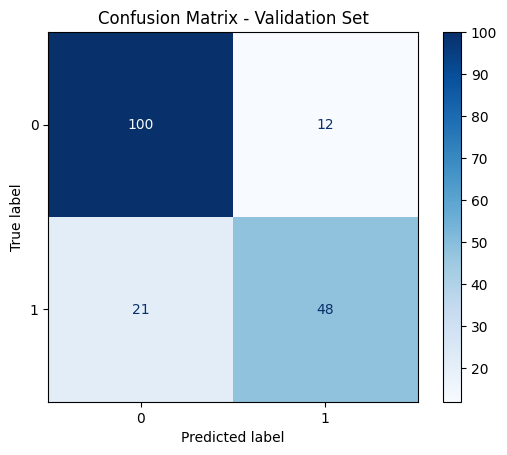

In [137]:
# Compute and display confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.show()

## 7 TensorFlow model

### 7.1 Define model

In [138]:
def build_binary_model(input_dim,
                       hidden_layer_sizes=[],
                       activation='relu',
                       optimizer='adam',
                       learning_rate=0.001,
                       metric='accuracy'):
    """
    Build a Keras binary classification model for tabular data.
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))

    for units in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units, activation=activation))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    if optimizer.lower() == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer. Use 'sgd' or 'adam'.")

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=[metric])
    return model


### 7.2 Build and compile

In [139]:
model = build_binary_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layer_sizes=[64, 32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    metric='accuracy'
)


### 7.3 Fit model

In [140]:
# Step 2: Optional early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Step 3: Fit the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
#    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50
17/17 - 1s - 64ms/step - accuracy: 0.6121 - loss: 0.6649 - val_accuracy: 0.6851 - val_loss: 0.6123
Epoch 2/50
17/17 - 0s - 4ms/step - accuracy: 0.7518 - loss: 0.5189 - val_accuracy: 0.7845 - val_loss: 0.5275
Epoch 3/50
17/17 - 0s - 10ms/step - accuracy: 0.8217 - loss: 0.4353 - val_accuracy: 0.8177 - val_loss: 0.4704
Epoch 4/50
17/17 - 0s - 7ms/step - accuracy: 0.8456 - loss: 0.3773 - val_accuracy: 0.8232 - val_loss: 0.4322
Epoch 5/50
17/17 - 0s - 9ms/step - accuracy: 0.8676 - loss: 0.3354 - val_accuracy: 0.8398 - val_loss: 0.4102
Epoch 6/50
17/17 - 0s - 6ms/step - accuracy: 0.8879 - loss: 0.3040 - val_accuracy: 0.8453 - val_loss: 0.3993
Epoch 7/50
17/17 - 0s - 4ms/step - accuracy: 0.8989 - loss: 0.2787 - val_accuracy: 0.8453 - val_loss: 0.3945
Epoch 8/50
17/17 - 0s - 4ms/step - accuracy: 0.9081 - loss: 0.2573 - val_accuracy: 0.8398 - val_loss: 0.3930
Epoch 9/50
17/17 - 0s - 4ms/step - accuracy: 0.9210 - loss: 0.2383 - val_accuracy: 0.8398 - val_loss: 0.3935
Epoch 10/50
17/17

### 7.4 Model results

In [141]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.3f}")

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f}")

# Classification report
y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_test_pred))


Validation Accuracy: 0.840
Test Accuracy: 0.780
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.84      0.79      0.82       112
           1       0.70      0.76      0.73        70

    accuracy                           0.78       182
   macro avg       0.77      0.78      0.77       182
weighted avg       0.78      0.78      0.78       182



## 8. Diagnosis: selecting top features using Random Forest

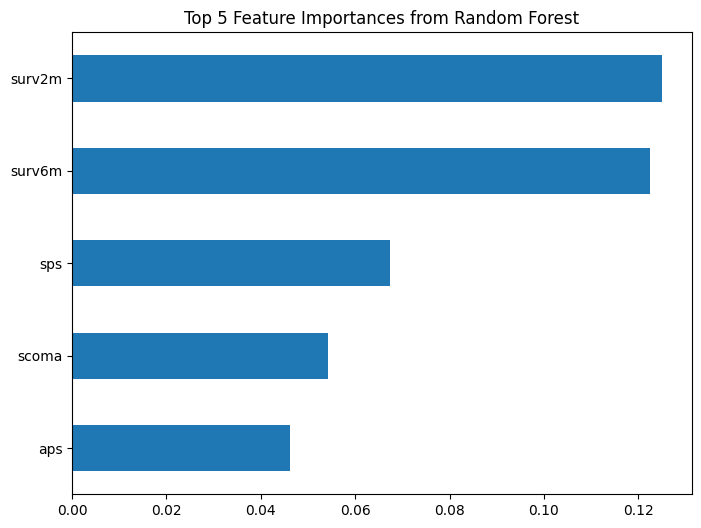

Top 5 features:
 ['surv2m', 'surv6m', 'sps', 'scoma', 'aps']


In [142]:
# Set number of top features to select
n = 5

# 1. Fit a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 2. Get feature importances
importances = rf.feature_importances_

# 3. Create Series and sort
feat_importance = pd.Series(importances, index=X_train.columns)
top_feats = feat_importance.sort_values(ascending=False).head(n)

# 4. Plot top n
top_feats.plot(kind="barh", figsize=(8, 6))
plt.title(f"Top {n} Feature Importances from Random Forest")
plt.gca().invert_yaxis()
plt.show()

# 5. Print list of top n feature names
top_n_feature_names = top_feats.index.tolist()
print(f"Top {n} features:\n", top_n_feature_names)


In [143]:
# 1. Use top_n_feature_names from previous cell
# If not defined yet:
# top_n_feature_names = top_feats.index.tolist()

# 2. Subset the scaled feature matrices
X_train_selected = X_train_scaled[:, [X_train.columns.get_loc(col) for col in top_n_feature_names]]
X_val_selected   = X_val_scaled[:, [X_val.columns.get_loc(col) for col in top_n_feature_names]]
X_test_selected  = X_test_scaled[:, [X_test.columns.get_loc(col) for col in top_n_feature_names]]


Validation Accuracy (top features): 0.773
Test Accuracy (top features): 0.709

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       112
           1       0.60      0.70      0.65        70

    accuracy                           0.71       182
   macro avg       0.70      0.71      0.70       182
weighted avg       0.72      0.71      0.71       182



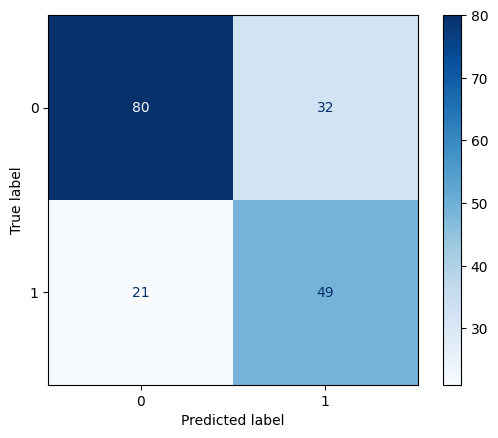

In [144]:
# Logistic regression on selected features
logreg_top = LogisticRegression(max_iter=10000)
logreg_top.fit(X_train_selected, y_train)

# Predict on validation and test sets
y_val_pred_top = logreg_top.predict(X_val_selected)
y_test_pred_top = logreg_top.predict(X_test_selected)

# Evaluation
print(f"Validation Accuracy (top features): {accuracy_score(y_val, y_val_pred_top):.3f}")
print(f"Test Accuracy (top features): {accuracy_score(y_test, y_test_pred_top):.3f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_top))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_top, cmap="Blues")


In [145]:
# Rebuild the model with smaller input shape
model_top = build_binary_model(
    input_dim=X_train_selected.shape[1],
    hidden_layer_sizes=[16, 8],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    metric='accuracy'
)

# Optional: early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Train on selected features
history_top = model_top.fit(
    X_train_selected, y_train,
    validation_data=(X_val_selected, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
val_loss_top, val_acc_top = model_top.evaluate(X_val_selected, y_val, verbose=0)
test_loss_top, test_acc_top = model_top.evaluate(X_test_selected, y_test, verbose=0)

print(f"Validation Accuracy (NN top features): {val_acc_top:.3f}")
print(f"Test Accuracy (NN top features): {test_acc_top:.3f}")

# Classification report
y_test_pred_nn = (model_top.predict(X_test_selected) > 0.5).astype(int)
print(classification_report(y_test, y_test_pred_nn))


Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3922 - loss: 0.7502 - val_accuracy: 0.5635 - val_loss: 0.7223
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5715 - loss: 0.7171 - val_accuracy: 0.6243 - val_loss: 0.6893
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6208 - loss: 0.6911 - val_accuracy: 0.6188 - val_loss: 0.6605
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6254 - loss: 0.6669 - val_accuracy: 0.6298 - val_loss: 0.6322
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6341 - loss: 0.6389 - val_accuracy: 0.6575 - val_loss: 0.6029
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6492 - loss: 0.6075 - val_accuracy: 0.7017 - val_loss: 0.5746
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6930 - loss: 0.5772 - val_accuracy: 0.7403 - val_loss: 0.5461
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7366 - loss: 0.5504 - val_accuracy: 0.7514 - val_loss